# Synthesize Movie

In [13]:
from PIL import Image, ImageSequence
import matplotlib.pyplot as plt
import numpy as np
import pickle
import torch
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn

torch.Size([1, 1, 80, 500, 500])


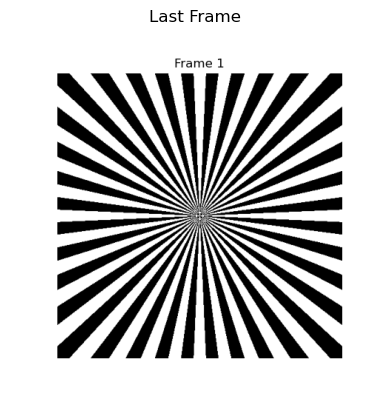

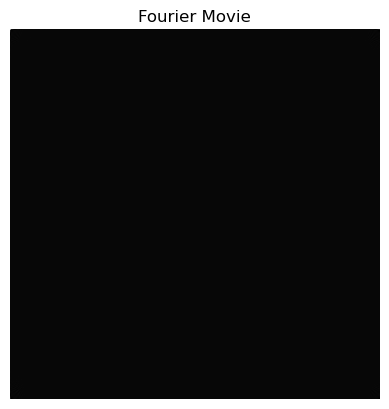

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

test_type = 'pinwheel' #'pinwheel'
n_movie_frames = 80

# Path to your AVI file
if(test_type=='pinwheel'):
    test_movie = './siemens_star/siemens_star_rotation.avi'
elif(test_type=='water'):
    test_movie = './texture_examples/water.mp4'

    
# Open the video file
cap = cv2.VideoCapture(test_movie)

# Check if the video opened successfully
if not cap.isOpened():
    print(f"Error: Unable to open video file '{test_movie}'")
    exit()

# Initialize list to store frames
movie = []
# Read frames from the video
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Convert frame to grayscale if necessary
    if frame.ndim > 2:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    movie.append(frame)

# Convert list of frames to numpy array & PyTorch tensor
movie = np.array(movie)
movie = torch.from_numpy(movie)
movie = movie.unsqueeze(0)  # Add a channel dimension (for grayscale)
movie = movie.unsqueeze(0)  # Add a channel dimension (for grayscale)
# Convert to float tensor (if needed)
movie = movie.float()
#take only the first n frames of the movie
movie = movie[:,:,:n_movie_frames,:,:]



fftmov = torch.fft.fftn(movie)
ufftmov = torch.fft.ifftn(fftmov)

print(movie.shape)
# if(test_movie=='pinwheel'):
plt.imshow(ufftmov[0][0][0].real, cmap='gray')  # Show the last frame
plt.title('Last Frame')
plt.axis('off')
plt.show()

plt.imshow(fftmov[0][0][0].real, cmap='gray')  # Show the last frame
plt.title('Fourier Movie')
plt.axis('off')
plt.show()


# Release the video capture object and close all windows
cap.release()
cv2.destroyAllWindows()



fftmov = torch.fft.fftn(movie)
#ufftmov = torch.fft.ifftn(fftmov)

In [10]:
#hyperparams
num_epochs = 100
num_crops = 5
#loss_func = losses.GeneralizedLiftedStructureLoss()
color = True
seed = 10
oris = 4
include_dphase_ims = False
edge_levels=6
edge_start=1
boundary_mode='wrap'#wrap'
mag_only=False
compress=False
top_rand_stats = None
top_n_stats = None #29655 #out of 28929
weights_to_load = None

optimize_gram_stats_indices = None
crop_size_t = 32
crop_size_x = 32
crop_size_y = 32
bottleneck_size = 100
batch_size = 1
seedimtype = 'rand'

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')


In [11]:
synth_load_folder = f'./saved_outputs/with_bandpass/average_stats_crop{crop_size}' 
if(seedimtype == 'avgenclearned'):
    print('Synth Seed Optimized from average encoding')
    synth = torch.load(os.path.join(synth_load_folder,f'learned_avg_encoding_img_{crop_size}.pt'))
elif(seedimtype == 'avg'):
    print('Synth Seed from average texture')
    synth = torch.load(os.path.join(synth_load_folder,f'avg_texture_img_{crop_size}.pt'))
else:
    #BW only for now
    synth = torch.randn([1,1,crop_size_t,crop_size_x,crop_size_y],device=device)*.1

In [18]:
#Set optimizer
optimizer = optim.LBFGS(
    [synth],
    max_iter = 100,
    tolerance_grad=0.0,
    tolerance_change=0.0,
    history_size=100,
    line_search_fn="strong_wolfe",
)

my_loss = nn.MSELoss()

n_iters = 1000
layers_weight = 1
log_every = 100

target = target.to(device)
synth = synth.to(device)
synth.requires_grad_(True)

print(target.shape)

torch.Size([1, 1, 32, 32, 32])


In [16]:
target = movie[:,:,:crop_size_t,:crop_size_x,:crop_size_y]


model = stn.StatTexGramNet(img_size=(crop_size,crop_size),
                                   batch_size=batch_size,
                                   bottleneck_size=bottleneck_size,
                                   device=device,
                                   #fourdim=True,
                                   compress=compress,
                                   color=color,
                                  add_marginals=True,
                                    add_pspec=False,
                                  oris=oris,
                                  edge_levels=edge_levels,
                                 edge_start=edge_start,
                                  include_dphase=include_dphase_ims,
                                 boundary_mode=boundary_mode,
                                 mag_only=mag_only)
model.to(device)
test = model(target)

NameError: name 'stn' is not defined